# Notebook 2: LSTM-SNP with Fuzzy Feature Augmentation

**Dataset**: Monthly Milk Production

## Description
This notebook implements **fuzzy feature augmentation** for the LSTM-SNP model. A Takagi-Sugeno 
fuzzy inference system processes the current and previous input values to generate an additional 
feature, which is concatenated with the original input before being fed into the unmodified 
LSTM-SNP cell.

The LSTM-SNP cell itself is **NOT modified** — only the input representation is enriched with 
fuzzy-derived features.

## Theory: Fuzzy Feature Augmentation

### LSTM-SNP Cell (Unchanged)
The LSTM-SNP cell equations remain exactly as in the baseline.

### Fuzzy Inference System
A Takagi-Sugeno fuzzy system augments the input:

**Membership Functions** (Fixed Gaussian):
- $\mu_{low}(x) = \exp\left(-\frac{(x - (-1))^2}{2 \cdot 0.5^2}\right)$
- $\mu_{high}(x) = \exp\left(-\frac{(x - (+1))^2}{2 \cdot 0.5^2}\right)$

**Rules** (4 Takagi-Sugeno rules):
1. IF $x(t)$ is low AND $x(t-1)$ is low → $y_1 = a_1 x(t) + b_1 x(t-1) + c_1$
2. IF $x(t)$ is low AND $x(t-1)$ is high → $y_2 = a_2 x(t) + b_2 x(t-1) + c_2$
3. IF $x(t)$ is high AND $x(t-1)$ is low → $y_3 = a_3 x(t) + b_3 x(t-1) + c_3$
4. IF $x(t)$ is high AND $x(t-1)$ is high → $y_4 = a_4 x(t) + b_4 x(t-1) + c_4$

**Defuzzification**: $y_{fuzzy} = \frac{\sum_i w_i y_i}{\sum_i w_i}$ where $w_i = \prod_j \mu_j(x_j)$

**Augmented Input**: $x'(t) = [x(t), y_{fuzzy}(t)]$

## Model Architecture & Implementation

In [ ]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
import os
print(f"Process ID (PID): {os.getpid()}")


In [ ]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
import time as _timer_module
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ============================================================
# GPU Acceleration Settings (CUDA + Apple Metal Support)
# ============================================================
import tensorflow as tf
import platform

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for device in physical_devices:
            tf.config.experimental.set_memory_growth(device, True)
        # Detect GPU type
        if platform.system() == 'Darwin' and platform.processor() == 'arm':
            print(f"Apple Metal GPU Enabled: Found {len(physical_devices)} GPU(s) via tensorflow-metal")
            print(f"  Chipset: Apple {platform.machine()} (M-series)")
        else:
            print(f"CUDA GPU Enabled: Found {len(physical_devices)} GPU(s) - Memory Growth Set")
        for d in physical_devices:
            print(f"  Device: {d.name}")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    if platform.system() == 'Darwin' and platform.processor() == 'arm':
        print("Apple Silicon detected but no GPU found.")
        print("  Install tensorflow-metal: pip install tensorflow-metal")
    else:
        print("No GPU found. Falling back to CPU.")
        print("  For CUDA: ensure NVIDIA drivers + CUDA toolkit are installed.")


In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.15.0
NumPy version: 1.26.4


### Fuzzy Inference System (NumPy — for preprocessing)

In [2]:
# ============================================================
# Fuzzy Inference System (NumPy — for preprocessing)
#
# Fixed Gaussian membership functions:
#   μ_low(x)  = exp(-(x - (-1))² / (2·0.5²))
#   μ_high(x) = exp(-(x - (+1))² / (2·0.5²))
#
# 4 Takagi-Sugeno rules with fixed consequent parameters:
#   IF x(t) is low  AND x(t-1) is low  → y₁ = 0.5·x(t) + 0.5·x(t-1)
#   IF x(t) is low  AND x(t-1) is high → y₂ = 0.7·x(t) + 0.3·x(t-1) - 0.1
#   IF x(t) is high AND x(t-1) is low  → y₃ = 0.3·x(t) + 0.7·x(t-1) + 0.1
#   IF x(t) is high AND x(t-1) is high → y₄ = 0.5·x(t) + 0.5·x(t-1)
#
# Output: y = Σ(wᵢ·yᵢ) / Σ(wᵢ)
# ============================================================

def gaussian_mf(x, center, sigma=0.5):
    """Fixed Gaussian membership function."""
    return np.exp(-(x - center)**2 / (2 * sigma**2))

def fuzzy_inference_numpy(x_t, x_tm1):
    """
    Compute fuzzy feature from x(t) and x(t-1).
    Uses fixed membership functions and fixed consequent parameters.
    """
    # Membership degrees
    mu_low_xt = gaussian_mf(x_t, center=-1.0)
    mu_high_xt = gaussian_mf(x_t, center=1.0)
    mu_low_xtm1 = gaussian_mf(x_tm1, center=-1.0)
    mu_high_xtm1 = gaussian_mf(x_tm1, center=1.0)

    # Rule firing strengths (product)
    w1 = mu_low_xt * mu_low_xtm1      # low-low
    w2 = mu_low_xt * mu_high_xtm1     # low-high
    w3 = mu_high_xt * mu_low_xtm1     # high-low
    w4 = mu_high_xt * mu_high_xtm1    # high-high

    # Consequent outputs (fixed linear functions)
    y1 = 0.5 * x_t + 0.5 * x_tm1
    y2 = 0.7 * x_t + 0.3 * x_tm1 - 0.1
    y3 = 0.3 * x_t + 0.7 * x_tm1 + 0.1
    y4 = 0.5 * x_t + 0.5 * x_tm1

    # Weighted average defuzzification
    numerator = w1 * y1 + w2 * y2 + w3 * y3 + w4 * y4
    denominator = w1 + w2 + w3 + w4 + 1e-8

    return numerator / denominator

### LSTM-SNP Cell

In [3]:
# ============================================================
# LSTM-SNP Cell (Original — Unmodified)
# ============================================================

class LSTMSNPCell(layers.Layer):
    """
    LSTM-SNP Cell: A long short-term memory model inspired from
    spiking neural P systems.

    Gates:
      r(t) = ρ(W_r x(t) + U_r u(t-1) + b_r)   [reset]
      c(t) = ρ(W_c x(t) + U_c u(t-1) + b_c)   [consumption]
      o(t) = ρ(W_o x(t) + U_o u(t-1) + b_o)   [output/generation]
      a(t) = f(W_a x(t) + U_a u(t-1) + b_a)   [generated spikes]

    State update:
      u(t) = r(t) * u(t-1) - c(t) * a(t)
      h(t) = o(t) * a(t)

    ρ = hard_sigmoid, f = tanh
    """
    def __init__(self, units,
                 activation='tanh',
                 recurrent_activation='hard_sigmoid',
                 **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units

        self.activation = tf.keras.activations.get(activation)
        self.recurrent_activation = tf.keras.activations.get(recurrent_activation)

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.kernel = self.add_weight(
            shape=(input_dim, self.units * 4),
            initializer='glorot_uniform',
            name='kernel'
        )
        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units * 4),
            initializer='orthogonal',
            name='recurrent_kernel'
        )
        self.bias = self.add_weight(
            shape=(self.units * 4,),
            initializer='zeros',
            name='bias'
        )

    def call(self, inputs, states):
        u_tm1 = states[0]

        z = tf.matmul(inputs, self.kernel) + \
            tf.matmul(u_tm1, self.recurrent_kernel) + self.bias

        z0 = z[:, :self.units]
        z1 = z[:, self.units:2*self.units]
        z2 = z[:, 2*self.units:3*self.units]
        z3 = z[:, 3*self.units:]

        r = self.recurrent_activation(z0)  # reset
        c = self.recurrent_activation(z1)  # consumption
        o = self.recurrent_activation(z2)  # output/generation
        a = self.activation(z3)            # generated spikes

        u = r * u_tm1 - c * a  # internal state
        h = o * a              # output

        return h, [u]

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
        })
        return config

### Build Model

In [4]:
# ============================================================
# Model Construction: LSTM-SNP with Fuzzy Feature Augmentation
# input_dim=2: [x(t), y_fuzzy(t)]
# The LSTM-SNP cell is UNMODIFIED.
# ============================================================

def build_model(input_dim, units, batch_size):
    cell = LSTMSNPCell(units)
    rnn = layers.RNN(cell, return_sequences=False, stateful=True)

    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x = rnn(inputs)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [5]:
# Quick model check
model = build_model(input_dim=2, units=8, batch_size=1)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(1, 1, 2)]               0         
                                                                 
 rnn (RNN)                   (1, 8)                    352       
                                                                 
 dense (Dense)               (1, 1)                    9         
                                                                 
Total params: 361 (1.41 KB)
Trainable params: 361 (1.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Data Pipeline — Monthly Milk Production


EVALUATING NOISE LEVEL: 0.5% (lambda=0.005, sigma=0.509499)

Data shape: (168,)
First 5 values: [589.25307559 560.92955441 640.32999695 656.77598287 726.88069898]
Supervised data shape: (167, 3)
Train: (107, 3), Test: (60, 3)
X_train shape: (107, 1, 2), y_train shape: (107,)

===== RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=778.0839, Expected=804.1312
Month=2, Predicted=774.0568, Expected=755.9621
Month=3, Predicted=849.0544, Expected=859.0224
Month=4, Predicted=864.6248, Expected=877.9865
Month=5, Predicted=934.8445, Expected=942.0307
Month=6, Predicted=907.0062, Expected=914.2550
Month=7, Predicted=870.4246, Expected=868.9020
Month=8, Predicted=814.7515, Expected=834.1536
Month=9, Predicted=800.7806, Expected=789.9823
Month=10, Predicted=795.8695, Expected=799.4046
Month=11, Predicted=785.3396, Expected=763.5823
Month=12, Predicted=781.3728, Expected=800.3831
Month=13, Predicted=827.9237, Expected=826.4030
Month=14, Predicted=807.3701, Expected=798.5367
Month=15, 

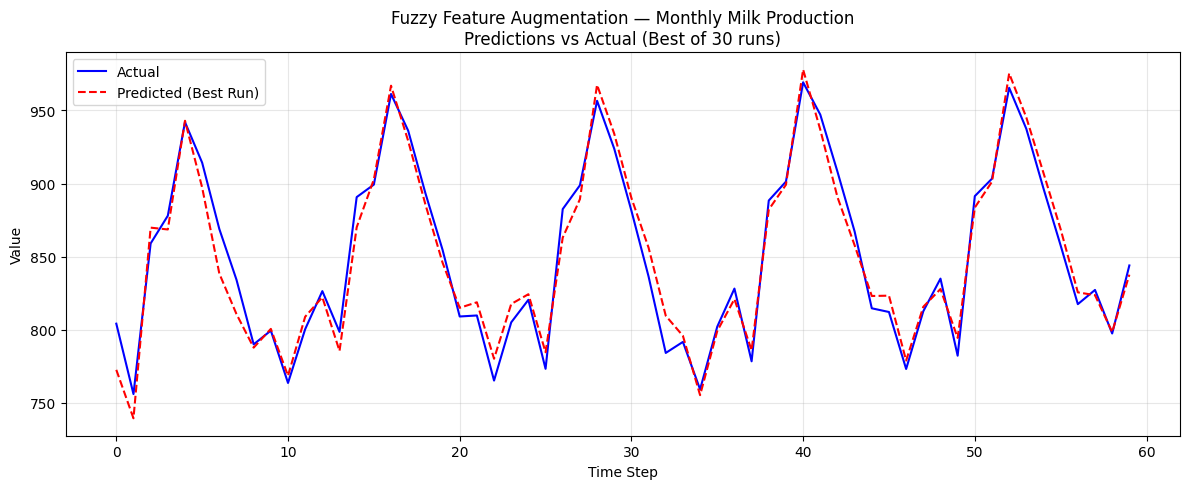

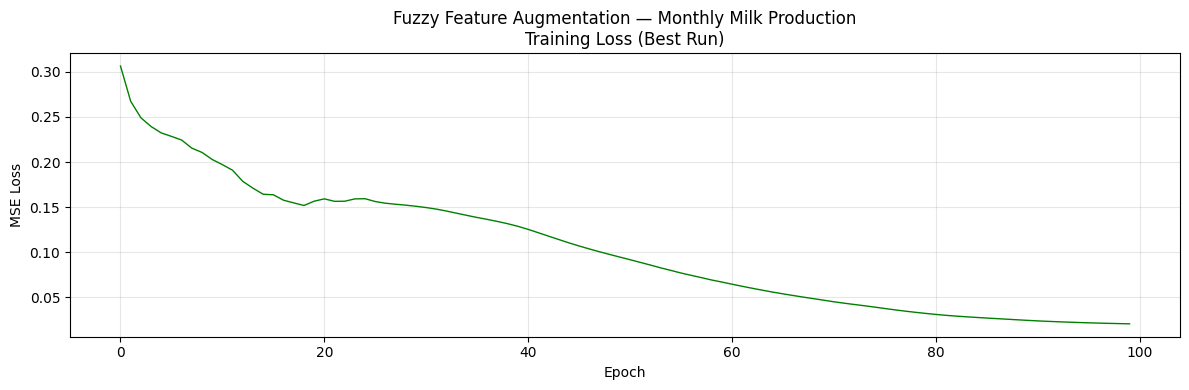

=== Best Run Metrics ===
RMSE: 11.847447
MSE:  140.362010
NMSE: 0.0006666041


In [6]:
# ============================================================
# 1. Load Time Series Data
# ============================================================

series = pd.read_csv(
    '../../content/monthly-milk-production-pounds-p.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()

import numpy as np
original_raw_values = np.copy(raw_values)
s_x = np.std(original_raw_values)
noise_levels = [0.005]

for lam in noise_levels:
    sigma = lam * s_x
    print("\n" + "="*80)
    print(f"EVALUATING NOISE LEVEL: {lam*100:.1f}% (lambda={lam}, sigma={sigma:.6f})")
    print("="*80 + "\n")
    
    np.random.seed(42)
    tf.random.set_seed(42)
    noise = np.random.normal(0, sigma, size=original_raw_values.shape)
    raw_values = original_raw_values + noise
    
    print(f"Data shape: {raw_values.shape}")
    print(f"First 5 values: {raw_values[:5]}")
    
    # ============================================================
    # 2. First-Order Differencing
    # ============================================================
    
    def difference(dataset, interval=1):
        diff = []
        for i in range(interval, len(dataset)):
            value = dataset[i] - dataset[i - interval]
            diff.append(value)
        return np.array(diff)
    
    diff_values = difference(raw_values, 1)
    
    # ============================================================
    # 3. Convert to Supervised Learning Format (lag=2)
    #    Needed for fuzzy feature augmentation: x(t), x(t-1)
    # ============================================================
    
    def timeseries_to_supervised(data, lag=1):
        df = pd.DataFrame(data)
        columns = [df.shift(i) for i in range(1, lag+1)]
        columns.append(df)
        df = pd.concat(columns, axis=1)
        df.fillna(0, inplace=True)
        return df.values
    
    supervised = timeseries_to_supervised(diff_values, 2)
    print(f"Supervised data shape: {supervised.shape}")
    
    # ============================================================
    # 4. Train-Test Split
    # ============================================================
    
    train, test = supervised[:-60], supervised[-60:]
    print(f"Train: {train.shape}, Test: {test.shape}")
    
    # ============================================================
    # 5. Feature Scaling
    # ============================================================
    
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train)
    
    train_scaled = scaler.transform(train)
    test_scaled = scaler.transform(test)
    
    # ============================================================
    # 6. Reshape for RNN Input (with Fuzzy Feature Augmentation)
    #    supervised columns: [x(t-2), x(t-1), x(t)]
    #    We use x(t-1) as primary input, x(t-2) for fuzzy context
    # ============================================================
    
    # Extract columns: col0=x(t-2), col1=x(t-1), col2=x(t) (target)
    X_train_raw = train_scaled[:, 0:-1]  # [x(t-2), x(t-1)]
    y_train = train_scaled[:, -1]        # x(t)
    
    X_test_raw = test_scaled[:, 0:-1]
    y_test = test_scaled[:, -1]
    
    # Compute fuzzy features for training data
    X_train_fuzzy = np.zeros((X_train_raw.shape[0], 2))  # [x(t-1), y_fuzzy]
    for i in range(X_train_raw.shape[0]):
        x_t = X_train_raw[i, 1]      # x(t-1) = current input
        x_tm1 = X_train_raw[i, 0]    # x(t-2) = previous input
        y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
        X_train_fuzzy[i, 0] = x_t
        X_train_fuzzy[i, 1] = y_fuzz
    
    X_train = X_train_fuzzy.reshape((X_train_fuzzy.shape[0], 1, 2))
    
    # Compute fuzzy features for test data
    X_test_fuzzy = np.zeros((X_test_raw.shape[0], 2))
    for i in range(X_test_raw.shape[0]):
        x_t = X_test_raw[i, 1]
        x_tm1 = X_test_raw[i, 0]
        y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
        X_test_fuzzy[i, 0] = x_t
        X_test_fuzzy[i, 1] = y_fuzz
    
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    
    # ============================================================
    # 30-Run Experiment Protocol
    # ============================================================
    
    all_rmse = []
    all_mse = []
    all_nmse = []
    all_predictions = []
    all_losses = []
    
    for run in range(30):
        print(f'\n===== RUN {run+1}/30 =====')
    
        np.random.seed(run)
        tf.random.set_seed(run)
    
        tf.keras.backend.clear_session()
        model = build_model(input_dim=2, units=8, batch_size=1)
    
        # Set consumption gate (c) bias to 1.0 (unit forget bias)
        rnn_layer = model.layers[1]
        cell = rnn_layer.cell
        weights = cell.get_weights()
        bias = weights[2].copy()
        bias[8:16] = 1.0  # units=8, bias[units:2*units]
        weights[2] = bias
        cell.set_weights(weights)
    
        # Training with manual epoch loop + reset_states
        run_losses = []
        for epoch in range(100):
            history = model.fit(
                X_train, y_train,
                epochs=1, batch_size=1,
                verbose=0, shuffle=False
            )
            run_losses.append(history.history['loss'][0])
            rnn_layer.reset_states()
    
        all_losses.append(run_losses)
        print(f'Training complete for run {run+1}')
    
        # Warm-up: condition hidden states on training data
        for i in range(len(train_scaled)):
            X_raw = train_scaled[i, 0:-1]
            x_t = X_raw[1]
            x_tm1 = X_raw[0]
            y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
            X_aug = np.array([x_t, y_fuzz]).reshape(1, 1, 2)
            model.predict(X_aug, batch_size=1, verbose=0)
    
        # Test predictions (single-step) with fuzzy feature augmentation
        predictions = []
        for i in range(len(test_scaled)):
            X_raw = test_scaled[i, 0:-1]  # [x(t-2), x(t-1)]
            x_t = X_raw[1]      # current input
            x_tm1 = X_raw[0]    # previous input
            y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
            X_aug = np.array([x_t, y_fuzz]).reshape(1, 1, 2)
            yhat = model.predict(X_aug, batch_size=1, verbose=0)[0, 0]
    
            # Invert scaling (need to match the scaler's column structure)
            # Scaler was fit on 3-column data [x(t-2), x(t-1), x(t)]
            new_row = list(X_raw) + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]
    
            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)
    
            expected = raw_values[len(train) + i + 1]
            print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')
    
        # Compute metrics
        actual = raw_values[-60:]
        rmse = sqrt(mean_squared_error(actual, predictions))
        mse = mean_squared_error(actual, predictions)
        meanV = np.mean(actual)
        dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
        nmse = mse / np.power(dominator, 2)
    
        all_rmse.append(rmse)
        all_mse.append(mse)
        all_nmse.append(nmse)
        all_predictions.append(predictions)
    
        print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')
    
    # ============================================================
    # Summary Statistics (30 runs)
    # ============================================================
    
    print('\n===== FINAL RESULTS — Fuzzy Feature Augmentation on Monthly Milk Production (30 runs) =====')
    print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
    print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
    print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')
    
    best_idx = np.argmin(all_rmse)
    print(f'\nBest run: {best_idx+1}')
    print(f'  RMSE: {all_rmse[best_idx]:.6f}')
    print(f'  MSE:  {all_mse[best_idx]:.6f}')
    print(f'  NMSE: {all_nmse[best_idx]:.10f}')
    
    # ============================================================
    # Predictions vs Actual (Best Run)
    # ============================================================
    
    actual = raw_values[-60:]
    best_predictions = all_predictions[best_idx]
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
    plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
             linewidth=1.5, linestyle='--')
    plt.title('Fuzzy Feature Augmentation — Monthly Milk Production\nPredictions vs Actual (Best of 30 runs)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # Loss Curve (Best Run)
    # ============================================================
    
    plt.figure(figsize=(12, 4))
    plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
    plt.title('Fuzzy Feature Augmentation — Monthly Milk Production\nTraining Loss (Best Run)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # Final Metrics Summary
    # ============================================================
    
    print('=== Best Run Metrics ===')
    print(f'RMSE: {all_rmse[best_idx]:.6f}')
    print(f'MSE:  {all_mse[best_idx]:.6f}')
    print(f'NMSE: {all_nmse[best_idx]:.10f}')
    


## Training Loop

## Results

## Observations

### Fuzzy Feature Augmentation on Monthly Milk Production

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with other variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Note training time per run

*After running all 5 variant notebooks, perform cross-variant comparison to evaluate 
whether fuzzy logic improves nonlinearity handling, interpretability, and prediction performance.*

In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
import time as _timer_module
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
